# Clasificación con Redes Neuronales — TMDB Dataset
**Proyecto:** Sistema de Recomendación de Películas basado en TMDB  
**Sección:** Clasificación — Redes Neuronales Artificiales  
**Dataset:** `pauguzman/tmdb_mineria_datos_processed` (HuggingFace)

Este notebook implementa dos tareas de clasificación:
- **Clasificación 1:** Predecir si una película es bien valorada (`highly_rated`, binaria)
- **Clasificación 2:** Predecir la categoría de éxito (`success_category`, multiclase: 4 clases)

Metodología: Validación cruzada estratificada 5-fold con Early Stopping.

---
## **0. de dependencias**

In [1]:
# Ejecutar solo si las librerías no están instaladas
# !pip install datasets tensorflow scikit-learn pandas numpy matplotlib -q

---
# **1. Imports**

In [2]:
# Instalar imbalanced-learn si no está disponible
# !pip install imbalanced-learn -q

In [3]:
# ── Datos ────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
from datasets import load_dataset

# ── Preprocesamiento ─────────────────────────────────────────────────────────
from sklearn.preprocessing import (
    LabelEncoder, MultiLabelBinarizer, StandardScaler
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

# ── Métricas ─────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, ConfusionMatrixDisplay,
    classification_report
)

# ── TensorFlow / Keras ───────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# ── Visualización ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Semillas para reproducibilidad ───────────────────────────────────────────
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)
print("Librerías cargadas correctamente.")

TensorFlow version: 2.20.0
Librerías cargadas correctamente.


---
# **2. Carga del dataset desde HuggingFace**

In [ ]:
ds = load_dataset("pauguzman/tmdb_mineria_datos_processed")
df = ds['train'].to_pandas()

print(f"Dataset: {df.shape[0]:,} películas | {df.shape[1]} variables")
print(f"\nColumnas disponibles:\n{list(df.columns)}")

---
# **3. Ingeniería de features y construcción de targets**

Se replica exactamente el mismo preprocesamiento que en los notebooks de Naive Bayes, Red Bayesiana y Random Forest para garantizar comparabilidad directa entre modelos.

Con el fin de garantizar una comparación justa entre los diferentes algoritmos evaluados (Naive Bayes, Red Bayesiana, Random Forest y Redes Neuronales), se replica exactamente el mismo proceso de preprocesamiento utilizado en las secciones anteriores del proyecto.

Esta etapa transforma las variables categóricas en representaciones numéricas adecuadas para los modelos de aprendizaje automático, preservando al mismo tiempo la información relevante del conjunto de datos.

En particular, se codifica el idioma original de las películas, se transforman variables booleanas y ordinales a formatos numéricos, y se aplica una codificación multietiqueta sobre los géneros cinematográficos.


Posteriormente, se definen los conjuntos de características utilizados para cada tarea de clasificación, excluyendo deliberadamente variables que podrían introducir fuga de información (data leakage), como componentes principales asociadas directamente con las variables objetivo o métricas altamente correlacionadas con ellas.

De esta manera, los modelos deben aprender patrones a partir de características estructurales y de contenido de las películas, permitiendo una evaluación más rigurosa y comparable de su capacidad predictiva.

In [5]:
# ── Codificar original_language (top 10 + 'other') ───────────────────────────
top_langs = df['original_language'].value_counts().nlargest(10).index
df['lang_encoded'] = df['original_language'].apply(
    lambda x: x if x in top_langs else 'other'
)
le = LabelEncoder()
df['lang_encoded'] = le.fit_transform(df['lang_encoded'])

# ── adult → entero ────────────────────────────────────────────────────────────
df['adult_int'] = df['adult'].astype(int)

# ── duration_bin → ordinal ────────────────────────────────────────────────────
duration_map = {'Short': 0, 'Standard': 1, 'Long': 2, 'Very long': 3}
df['duration_encoded'] = df['duration_bin'].map(duration_map)

# ── Géneros con MultiLabelBinarizer ──────────────────────────────────────────
df['genres_list'] = df['genres'].fillna('').apply(
    lambda x: [g.strip() for g in x.split(',') if g.strip() != '']
)
mlb = MultiLabelBinarizer()
genres_encoded = mlb.fit_transform(df['genres_list'])
df_genres = pd.DataFrame(
    genres_encoded,
    columns=[f'genre_{g}' for g in mlb.classes_],
    index=df.index
)
GENRE_COLS = list(df_genres.columns)
print(f"Géneros codificados ({len(GENRE_COLS)}): {GENRE_COLS}")

# ── Features Clasificación 1 — highly_rated ───────────────────────────────────
# EXCLUYE: todas las PCs (PC1–PC5 cargan vote_average, que define el target),
#          vote_count (correlaciona con vote_average, r=0.23 según EDA).
# INCLUYE: características estructurales y de contenido independientes del rating.
FEATURES_C1 = [
    'runtime', 'release_year', 'adult_int',
    'lang_encoded', 'duration_encoded'
] + GENRE_COLS  # 5 + 19 = 24 features

# ── Features Clasificación 2 — success_category ───────────────────────────────
# success_category = highly_rated + popularity.
# EXCLUYE: todas las PCs (PC3 carga vote_count 0.52 y popularity 0.61,
#          reconstruyendo el target), vote_count (correlaciona con popularity).
# INCLUYE: solo features estructurales y de contenido: runtime, release_year,
#          adult_int, lang_encoded, duration_encoded y géneros.
# Con estas features el modelo debe inferir popularidad y calidad
# desde el tipo de contenido, no desde métricas de interacción.
FEATURES_C2 = [
    'runtime', 'release_year', 'adult_int',
    'lang_encoded', 'duration_encoded'
] + GENRE_COLS  # 5 + 19 = 24 features

print(f"\nFeatures Clasificación 1 (highly_rated):     {len(FEATURES_C1)} columnas")
print(f"  → Sin PCs ni vote_count (evita leakage con vote_average)")
print(f"Features Clasificación 2 (success_category): {len(FEATURES_C2)} columnas")
print(f"  → Sin PCs ni vote_count (evita leakage con popularity/highly_rated)")


Géneros codificados (19): ['genre_Action', 'genre_Adventure', 'genre_Animation', 'genre_Comedy', 'genre_Crime', 'genre_Documentary', 'genre_Drama', 'genre_Family', 'genre_Fantasy', 'genre_History', 'genre_Horror', 'genre_Music', 'genre_Mystery', 'genre_Romance', 'genre_Science Fiction', 'genre_TV Movie', 'genre_Thriller', 'genre_War', 'genre_Western']

Features Clasificación 1 (highly_rated):     24 columnas
  → Sin PCs ni vote_count (evita leakage con vote_average)
Features Clasificación 2 (success_category): 24 columnas
  → Sin PCs ni vote_count (evita leakage con popularity/highly_rated)


Una vez definidas las características de entrada, se procede a la construcción de las variables objetivo utilizadas en las tareas de clasificación:


- La primera tarea corresponde a la predicción de **highly_rated**, una variable binaria ya presente en el conjunto de datos procesado que indica si una película ha recibido una valoración alta por parte de los usuarios.

- La segunda tarea consiste en predecir **success_category**, una variable multiclase construida a partir de la combinación de la valoración de la película (highly_rated) y su nivel de popularidad. Esta categorización permite distinguir entre películas exitosas tanto en calidad como en alcance comercial, películas reconocidas por la crítica, éxitos comerciales y producciones estándar.



Finalmente, se generan las matrices de características (X) y los vectores objetivo (y) que serán utilizados posteriormente para el entrenamiento y evaluación de los modelos de clasificación.

In [6]:
# ── Target 1: highly_rated (ya existe en el dataset procesado) ────────────────

# ── Target 2: success_category (construido igual que en NB y RF) ─────────────
pop_threshold = df['popularity'].quantile(0.75)

conditions = [
    (df['highly_rated'] == 1) & (df['popularity'] > pop_threshold),
    (df['highly_rated'] == 1) & (df['popularity'] <= pop_threshold),
    (df['highly_rated'] == 0) & (df['popularity'] > pop_threshold),
    (df['highly_rated'] == 0) & (df['popularity'] <= pop_threshold),
]

choices = ['Success', 'Critically Acclaimed', 'Commercial Hit', 'Standard']
df['success_category'] = np.select(
    conditions, choices, default='Standard'
).astype(str)

# Codificar target 2 a enteros
le_target = LabelEncoder()
df['success_category_enc'] = le_target.fit_transform(df['success_category'])
CLASS_NAMES = le_target.classes_  # orden alfabético: Commercial Hit, Critically Acclaimed, Standard, Success

print("── Target 1: highly_rated ──────────────────────────────")
print(df['highly_rated'].value_counts(normalize=True).round(3))
print("\n── Target 2: success_category ──────────────────────────")
print(df['success_category'].value_counts(normalize=True).round(3))
print(f"\nClases codificadas: {list(zip(CLASS_NAMES, range(len(CLASS_NAMES))))}")

# ── Construir matrices X e y ──────────────────────────────────────────────────
df_full = pd.concat([df, df_genres], axis=1)

X_c1 = df_full[FEATURES_C1].values.astype(np.float32)
X_c2 = df_full[FEATURES_C2].values.astype(np.float32)
y1     = df['highly_rated'].values.astype(np.int32)
y2_enc = df['success_category_enc'].values.astype(np.int32)

print(f"\nX_c1 shape: {X_c1.shape}")
print(f"X_c2 shape: {X_c2.shape}")
print(f"y1   shape: {y1.shape} | clases: {np.unique(y1)}")
print(f"y2   shape: {y2_enc.shape} | clases: {np.unique(y2_enc)}")

── Target 1: highly_rated ──────────────────────────────
highly_rated
0    0.832
1    0.168
Name: proportion, dtype: float64

── Target 2: success_category ──────────────────────────
success_category
Standard                0.642
Commercial Hit          0.190
Critically Acclaimed    0.108
Success                 0.060
Name: proportion, dtype: float64

Clases codificadas: [('Commercial Hit', 0), ('Critically Acclaimed', 1), ('Standard', 2), ('Success', 3)]

X_c1 shape: (116929, 24)
X_c2 shape: (116929, 24)
y1   shape: (116929,) | clases: [0 1]
y2   shape: (116929,) | clases: [0 1 2 3]


El análisis de la distribución de las variables objetivo evidencia un importante desbalance de clases en ambos problemas de clasificación. Para la variable **highly_rated**, únicamente el **16.8%** de las películas corresponde a valoraciones altas, mientras que el **83.2%** pertenece a la clase negativa. Esta distribución implica que un modelo podría alcanzar una precisión aparentemente elevada simplemente favoreciendo la clase mayoritaria, por lo que métricas como *precision*, *recall*, *F1-score* y *AUC* resultan especialmente relevantes para evaluar el desempeño real.

De manera similar, la variable multiclase **success_category** presenta una distribución desigual, donde la categoría **Standard** concentra el **64.2%** de las observaciones, seguida por **Commercial Hit** (19.0%), **Critically Acclaimed** (10.8%) y **Success** (6.0%). Esto convierte a las categorías más exitosas en clases minoritarias cuya identificación representa un desafío adicional para los modelos de aprendizaje automático. Finalmente, las matrices de entrada para ambas tareas quedaron conformadas por **116,929 registros y 24 características predictoras**, proporcionando un volumen de datos considerable para el entrenamiento de modelos supervisados y permitiendo evaluar su capacidad de generalización sobre una muestra amplia y diversa de películas.


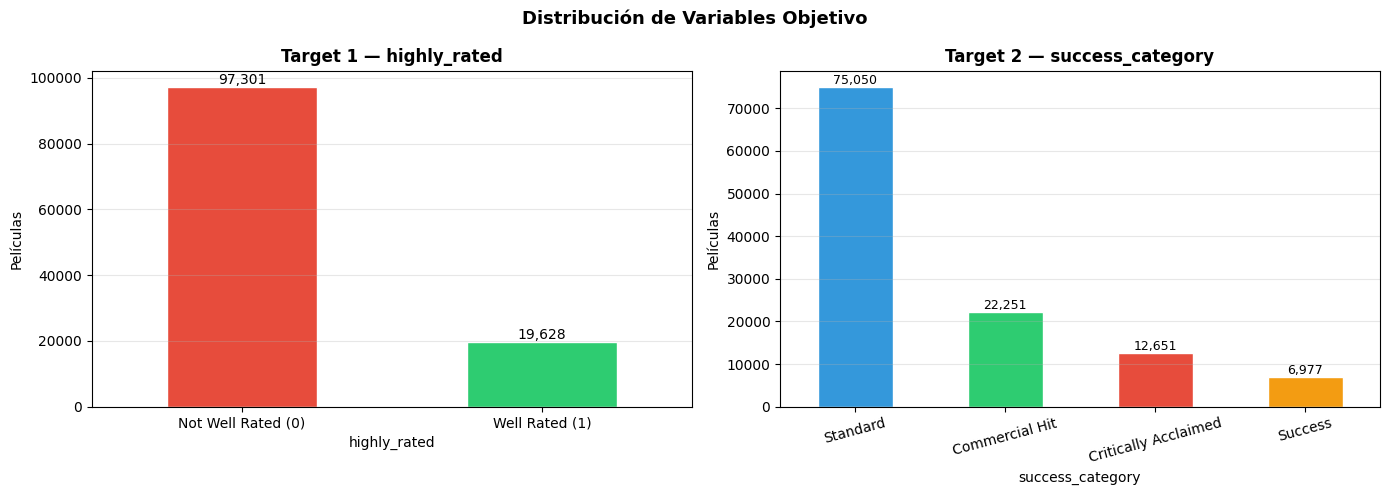

In [7]:
# ── Visualización distribución de targets ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['highly_rated'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['#e74c3c', '#2ecc71'], edgecolor='white', rot=0
)
axes[0].set_title('Target 1 — highly_rated', fontweight='bold')
axes[0].set_xticklabels(['Not Well Rated (0)', 'Well Rated (1)'])
axes[0].set_ylabel('Películas')
axes[0].grid(alpha=0.3, axis='y')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

df['success_category'].value_counts().plot(
    kind='bar', ax=axes[1],
    color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'],
    edgecolor='white', rot=15
)
axes[1].set_title('Target 2 — success_category', fontweight='bold')
axes[1].set_ylabel('Películas')
axes[1].grid(alpha=0.3, axis='y')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),ha='center', va='bottom', fontsize=9)

plt.suptitle('Distribución de Variables Objetivo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

La Figura muestra la distribución de las variables objetivo utilizadas en las dos tareas de clasificación. En el caso de **highly_rated**, se observa un marcado desbalance entre las clases: de las 116,929 películas analizadas, **97,301 (83.2%)** corresponden a películas no altamente valoradas, mientras que solo **19,628 (16.8%)** pertenecen a la categoría de películas bien valoradas. Esta diferencia evidencia que la identificación de películas altamente calificadas constituye un problema de clasificación desbalanceado, lo que justifica el uso de métricas complementarias a la exactitud y técnicas de ponderación de clases durante el entrenamiento de los modelos.

Por otra parte, la distribución de **success_category** revela una concentración significativa en la categoría **Standard**, con **75,050 películas (64.2%)**, seguida por **Commercial Hit** con **22,251 registros (19.0%)**, **Critically Acclaimed** con **12,651 registros (10.8%)** y **Success** con apenas **6,977 películas (6.0%)**. Esto indica que las películas que alcanzan simultáneamente altos niveles de popularidad y valoración constituyen una minoría dentro del conjunto de datos. En consecuencia, la clasificación multiclase resulta más desafiante, ya que los modelos deberán aprender a distinguir categorías poco representadas frente a una clase dominante. La gráfica permite visualizar claramente este desbalance y anticipa la necesidad de estrategias que mitiguen el sesgo hacia las clases mayoritarias durante el proceso de aprendizaje.


---
# **4. Escalado de features**

Se aplica `StandardScaler` globalmente sobre `X_c1` y `X_c2`. Esto es válido porque las componentes PCA ya están centradas por construcción y la mayoría de features categóricas tienen rango acotado. Se documenta como simplificación consistente con el resto del notebook.

**Escalado de características**

Las redes neuronales suelen beneficiarse de que las variables de entrada se encuentren en escalas similares, ya que esto favorece la estabilidad numérica durante el proceso de optimización y acelera la convergencia del entrenamiento. Por esta razón, se aplica la técnica de estandarización mediante StandardScaler, la cual transforma cada característica para que tenga media cercana a cero y desviación estándar cercana a uno. De esta forma, ninguna variable domina el aprendizaje únicamente por presentar valores numéricamente más grandes que las demás, permitiendo que la red neuronal aproveche de manera más equilibrada la información contenida en cada atributo.

In [8]:
scaler_c1 = StandardScaler()
X_c1_scaled = scaler_c1.fit_transform(X_c1)

scaler_c2 = StandardScaler()
X_c2_scaled = scaler_c2.fit_transform(X_c2)

print(f"X_c1_scaled shape: {X_c1_scaled.shape}")
print(f"  Media  (~0): {X_c1_scaled.mean():.6f}")
print(f"  Std    (~1): {X_c1_scaled.std():.6f}")

print(f"\nX_c2_scaled shape: {X_c2_scaled.shape}")
print(f"  Media  (~0): {X_c2_scaled.mean():.6f}")
print(f"  Std    (~1): {X_c2_scaled.std():.6f}")

X_c1_scaled shape: (116929, 24)
  Media  (~0): 0.000000
  Std    (~1): 1.000000

X_c2_scaled shape: (116929, 24)
  Media  (~0): 0.000000
  Std    (~1): 1.000000


Los resultados confirman que el proceso de estandarización se realizó correctamente para ambos conjuntos de datos. Tanto **X_c1_scaled** como **X_c2_scaled** conservan sus dimensiones originales de **116,929 registros y 24 características**, mientras que la media global de las variables transformadas es prácticamente **0** y la desviación estándar es aproximadamente **1**. Estas propiedades son precisamente el objetivo de *StandardScaler* y garantizan que todas las características contribuyan de forma comparable durante el entrenamiento. En consecuencia, las redes neuronales podrán optimizar sus pesos de manera más eficiente, reduciendo problemas asociados a diferencias de escala entre variables y favoreciendo una convergencia más estable del algoritmo de aprendizaje.


---
# **5. Arquitecturas de los modelos**

Se definen dos funciones constructoras:
- **Binaria:** capa de salida con activación `sigmoid` y pérdida `binary_crossentropy`
- **Multiclase:** capa de salida con activación `softmax` y pérdida `sparse_categorical_crossentropy`

Ambas usan la misma arquitectura backbone: `Dense(64, relu) → Dropout(0.3) → Dense(32, relu) → Dropout(0.3)`, optimizador Adam.

En este trabajo se emplean perceptrones multicapa (Multilayer Perceptrons o MLP), una arquitectura adecuada para datos tabulares como los utilizados en el conjunto TMDB. Las capas ocultas permiten aprender relaciones no lineales entre las características de las películas y las variables objetivo, mientras que técnicas como Batch Normalization y Dropout ayudan a mejorar la estabilidad del entrenamiento y reducir el sobreajuste. Se construyen dos modelos con la misma estructura base para garantizar la comparabilidad de resultados, diferenciándose únicamente en la capa de salida y la función de pérdida según la naturaleza de cada tarea de clasificación.

In [9]:
def build_model_binary(input_dim):
    """Red neuronal para clasificación binaria (highly_rated).
    Arquitectura: 128→64→32 con BatchNormalization y Dropout.
    BatchNorm acelera convergencia y reduce sensibilidad al learning rate.
    """
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


def build_model_multiclass(input_dim, n_classes):
    """Red neuronal para clasificación multiclase (success_category).
    Misma arquitectura 128→64→32 con BatchNorm para consistencia.
    """
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(n_classes, activation='softmax')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# ── Mostrar arquitecturas ─────────────────────────────────────────────────────
print("── Arquitectura Clasificación 1 (binaria) ──────────────")
build_model_binary(len(FEATURES_C1)).summary()

print("\n── Arquitectura Clasificación 2 (multiclase) ───────────")
build_model_multiclass(len(FEATURES_C2), 4).summary()


── Arquitectura Clasificación 1 (binaria) ──────────────


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,337 (56.00 KB)

 Trainable params: 13,953 (54.50 KB)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,436 (56.39 KB)

 Trainable params: 14,052 (54.89 KB)

 Non-trainable params: 384 (1.50 KB)

**Análisis de la arquitectura**


Los dos modelos presentan una estructura prácticamente idéntica, compuesta por tres capas densas de 128, 64 y 32 neuronas respectivamente.

Esta configuración proporciona suficiente capacidad para capturar patrones complejos sin llegar a ser excesivamente grande para un conjunto de datos con únicamente 24 variables de entrada. La incorporación de capas de Batch Normalization contribuye a estabilizar y acelerar el proceso de aprendizaje, mientras que los niveles progresivos de Dropout (0.4, 0.3 y 0.2) actúan como mecanismo de regularización para reducir el riesgo de sobreajuste.



Asimismo, el número total de parámetros entrenables es relativamente bajo (aproximadamente 14 mil), lo que implica un costo computacional reducido en comparación con arquitecturas profundas más complejas. La diferencia principal entre ambos modelos se encuentra en la capa de salida: la red para highly_rated utiliza una única neurona con activación sigmoid para estimar probabilidades binarias, mientras que la red para success_category emplea cuatro neuronas con activación softmax para distribuir la probabilidad entre las cuatro clases posibles. Esta adaptación permite abordar cada problema de clasificación de manera adecuada manteniendo una arquitectura consistente en todo el estudio.

> Las capas **Dense** son las encargadas de aprender patrones y relaciones entre las características de las películas. La función de activación **ReLU** introduce no linealidad para modelar comportamientos más complejos. Las capas de **Batch Normalization** estabilizan y aceleran el entrenamiento al normalizar las activaciones internas, mientras que las capas de **Dropout** desactivan aleatoriamente una fracción de neuronas durante el entrenamiento para reducir el sobreajuste. Finalmente, la capa de salida utiliza **sigmoid** para la clasificación binaria (*highly_rated*) y **softmax** para la clasificación multiclase (*success_category*).


---
# **6. Función de validación cruzada para redes neuronales**

Implementación manual de 5-fold estratificado porque scikit-learn no soporta modelos Keras nativamente. Dentro de cada fold:
1. Se calcula `class_weight` con `compute_class_weight('balanced')` de sklearn (más formal que el cálculo manual).
2. Se construye el modelo desde cero (pesos aleatorios) para evitar data leakage entre folds.
3. Se usa Early Stopping con `patience=5` monitoreando `val_loss` sobre el 15% de validación interno.
4. El fold 5 se conserva para visualizaciones (curvas de entrenamiento y matriz de confusión).

Para la evaluación de modelos se implementó una validación cruzada estratificada de 5 particiones (5-fold cross-validation), garantizando que la distribución de clases se mantenga similar en cada subconjunto de entrenamiento y prueba.


Adicionalmente, debido al desbalance presente en los datos, se incorpora la técnica SMOTE (Synthetic Minority Over-sampling Technique) dentro de cada fold para generar ejemplos sintéticos de las clases minoritarias únicamente sobre el conjunto de entrenamiento. También se emplea Early Stopping para detener automáticamente el entrenamiento cuando la pérdida de validación deja de mejorar, reduciendo el riesgo de sobreajuste y disminuyendo el tiempo computacional necesario.

In [10]:
def evaluar_nn_cv(
    X, y, build_fn, task='binary',
    n_splits=5, epochs=100, batch_size=512, patience=10
):
    """
    Validación cruzada estratificada 5-fold para redes neuronales Keras.

    Parámetros
    ----------
    X        : np.ndarray — features escaladas
    y        : np.ndarray — target (int)
    build_fn : callable  — función que construye y compila el modelo
    task     : 'binary' | 'multiclass'
    n_splits : número de folds (5)
    epochs   : máximo de épocas por fold (50)
    batch_size: 256 — eficiente para datasets grandes (~116k registros)
    patience : épocas sin mejora antes de detener entrenamiento (5)

    Retorna
    -------
    metricas_finales : dict con promedios de Accuracy, Precision, Recall, F1, AUC
    historiales      : list de history.history de cada fold
    last_y_test      : y real del fold 5
    last_y_pred      : predicciones del fold 5
    last_y_prob      : probabilidades del fold 5
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    resultados  = []
    historiales = []
    last_y_test = last_y_pred = last_y_prob = None

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        print(f"  Fold {fold+1}/{n_splits}...", end=' ')

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # ── SMOTE: sobremuestreo de clase minoritaria dentro del fold ─────────
        # Se aplica SOLO sobre train para no contaminar el test set.
        # k_neighbors=5 (default): cada muestra sintética se genera interpolando
        # entre un ejemplo real y uno de sus 5 vecinos más cercanos.
        try:
            smote = SMOTE(random_state=42, k_neighbors=5)
            X_train, y_train = smote.fit_resample(X_train, y_train)
            print(f'(SMOTE: {len(y_train):,} muestras)', end=' ')
        except Exception as e:
            print(f'(SMOTE omitido: {e})', end=' ')

        # ── class_weight = None porque SMOTE ya balanceó las clases ──────────
        cw = None

        # ── Modelo fresco en cada fold (evita data leakage) ──────────────────
        n_classes = len(np.unique(y))
        if task == 'binary':
            model = build_fn(X.shape[1])
        else:
            model = build_fn(X.shape[1], n_classes)

        # ── Early Stopping ───────────────────────────────────────────────────
        es = EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True,
            verbose=0
        )

        # ── Entrenamiento (85% train / 15% val interna para Early Stopping) ──
        history = model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=0.20,
            callbacks=[es],
            class_weight=cw,
            verbose=0
        )
        historiales.append(history.history)

        # ── Predicciones sobre test del fold ─────────────────────────────────
        if task == 'binary':
            y_prob = model.predict(X_test, verbose=0).flatten()
            y_pred = (y_prob >= 0.5).astype(int)
            auc    = roc_auc_score(y_test, y_prob)
        else:
            y_prob = model.predict(X_test, verbose=0)
            y_pred = np.argmax(y_prob, axis=1)
            auc    = roc_auc_score(
                y_test, y_prob,
                multi_class='ovr', average='weighted'
            )

        # ── Métricas del fold ────────────────────────────────────────────────
        avg = 'binary' if task == 'binary' else 'weighted'
        fold_result = {
            'accuracy':   accuracy_score(y_test, y_pred),
            'precision':  precision_score(y_test, y_pred,
                              average=avg, zero_division=0),
            'recall':     recall_score(y_test, y_pred,
                              average=avg, zero_division=0),
            'f1':         f1_score(y_test, y_pred,
                              average=avg, zero_division=0),
            'auc':        auc,
            'epochs_run': len(history.history['loss'])
        }
        resultados.append(fold_result)
        print(
            f"F1={fold_result['f1']:.4f} | "
            f"AUC={fold_result['auc']:.4f} | "
            f"épocas={fold_result['epochs_run']}"
        )

        # Guardar último fold para visualización
        last_y_test = y_test
        last_y_pred = y_pred
        last_y_prob = y_prob

    # ── Promediar métricas ───────────────────────────────────────────────────
    metricas_finales = {
        'Modelo':           '',
        'Accuracy':         round(np.mean([r['accuracy']   for r in resultados]), 4),
        'Precision':        round(np.mean([r['precision']  for r in resultados]), 4),
        'Recall':           round(np.mean([r['recall']     for r in resultados]), 4),
        'F1-Score':         round(np.mean([r['f1']         for r in resultados]), 4),
        'AUC':              round(np.mean([r['auc']        for r in resultados]), 4),
        'Épocas promedio':  round(np.mean([r['epochs_run'] for r in resultados]), 1)
    }

    print(f"\n  {'─'*50}")
    print(f"  Promedio 5-fold:")
    for k, v in metricas_finales.items():
        if k not in ('Modelo', 'Épocas promedio'):
            print(f"     {k:12}: {v:.4f}")
    print(f"  Épocas promedio : {metricas_finales['Épocas promedio']}")

    return metricas_finales, historiales, last_y_test, last_y_pred, last_y_prob


print("Función evaluar_nn_cv definida correctamente.")

Función evaluar_nn_cv definida correctamente.


La función evaluar_nn_cv centraliza todo el proceso de entrenamiento y evaluación de las redes neuronales. En cada fold se realiza el balanceo de clases mediante SMOTE, se construye un modelo completamente nuevo para evitar filtración de información entre particiones y se entrena utilizando un conjunto interno de validación para controlar el Early Stopping. Posteriormente, el modelo se evalúa sobre datos no vistos mediante métricas de clasificación como Accuracy, Precision, Recall, F1-Score y AUC. Finalmente, los resultados de los cinco folds son promediados para obtener una estimación más estable y representativa del desempeño real de la red neuronal sobre el problema de clasificación.

> Dado que los géneros fueron codificados mediante variables binarias (one-hot encoding), la aplicación de SMOTE genera muestras sintéticas mediante interpolación numérica entre observaciones cercanas. Aunque los valores resultantes pueden no corresponder a combinaciones categóricas reales, esta aproximación permite mejorar la representación de las clases minoritarias durante el entrenamiento de la red neuronal.

---
# **7. Clasificación 1: `highly_rated` (binaria)**
### Entrenamiento con validación cruzada 5-fold

In [11]:
print("═"*55)
print("  CLASIFICACIÓN 1: highly_rated — Red Neuronal")
print("═"*55)

res_nn1, hist_nn1, yt1, yp1, yprob1 = evaluar_nn_cv(
    X_c1_scaled, y1,
    build_fn=build_model_binary,
    task='binary',
    n_splits=5,
    epochs=100,
    batch_size=512,
    patience=10
)
res_nn1['Modelo'] = 'Red Neuronal — highly_rated'

═══════════════════════════════════════════════════════
  CLASIFICACIÓN 1: highly_rated — Red Neuronal
═══════════════════════════════════════════════════════
  Fold 1/5... (SMOTE: 155,682 muestras) F1=0.4282 | AUC=0.7573 | épocas=33
  Fold 2/5... (SMOTE: 155,682 muestras) F1=0.3896 | AUC=0.7304 | épocas=11
  Fold 3/5... (SMOTE: 155,682 muestras) F1=0.4352 | AUC=0.7676 | épocas=67
  Fold 4/5... (SMOTE: 155,680 muestras) F1=0.4354 | AUC=0.7653 | épocas=73
  Fold 5/5... (SMOTE: 155,682 muestras) F1=0.4296 | AUC=0.7634 | épocas=63

  ──────────────────────────────────────────────────
  Promedio 5-fold:
     Accuracy    : 0.7621
     Precision   : 0.3570
     Recall      : 0.5220
     F1-Score    : 0.4236
     AUC         : 0.7568
  Épocas promedio : 49.4


Los resultados muestran un desempeño consistente entre los distintos folds, con valores de AUC cercanos a 0.76, lo que indica una capacidad razonable para distinguir entre ambas clases. El modelo alcanzó una Accuracy promedio de 76.21%, aunque esta métrica debe interpretarse con cautela debido al desbalance de la variable objetivo. El Recall de 52.2% indica que la red logra identificar aproximadamente la mitad de las películas altamente valoradas, mientras que la Precision de 35.7% refleja la dificultad de predecir correctamente una clase positiva que representa únicamente el 16.8% del conjunto de datos. Como resultado, el F1-Score promedio de 0.4236 evidencia un compromiso moderado entre precisión y sensibilidad. Adicionalmente, el Early Stopping detuvo el entrenamiento en un promedio de 49.4 épocas, evitando continuar el aprendizaje una vez que las mejoras en validación se volvieron marginales.

### **Curvas de entrenamiento — Clasificación 1 (Fold 5)**

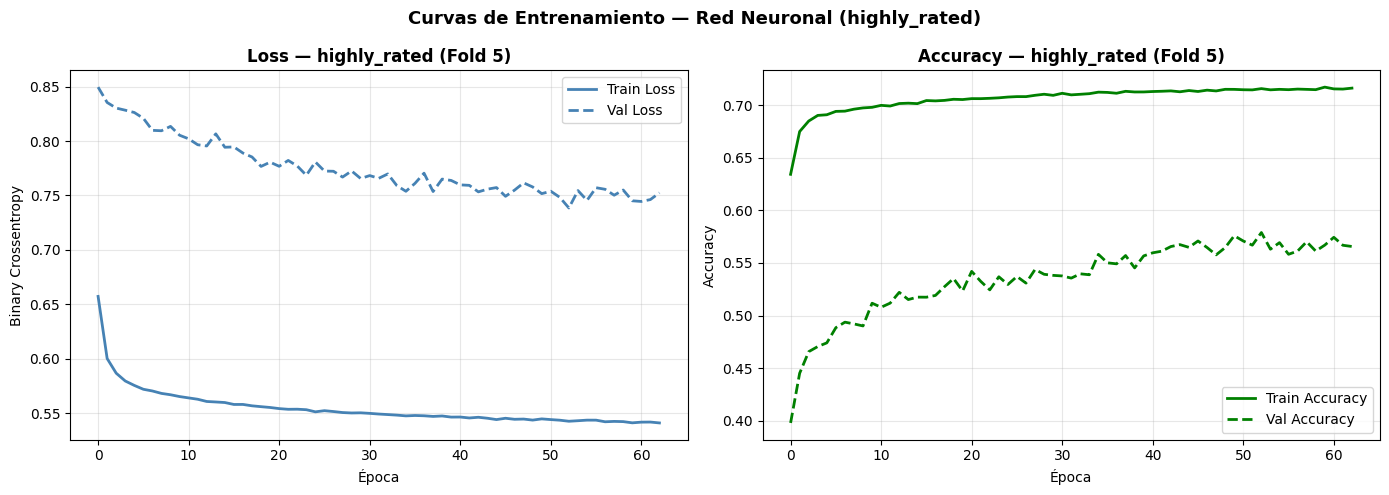

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Loss ─────────────────────────────────────────────────────────────────────
axes[0].plot(hist_nn1[-1]['loss'],
             label='Train Loss', color='steelblue', linewidth=2)
axes[0].plot(hist_nn1[-1]['val_loss'],
             label='Val Loss', color='steelblue', linestyle='--', linewidth=2)
axes[0].set_title('Loss — highly_rated (Fold 5)', fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Accuracy ──────────────────────────────────────────────────────────────────
axes[1].plot(hist_nn1[-1]['accuracy'],
             label='Train Accuracy', color='green', linewidth=2)
axes[1].plot(hist_nn1[-1]['val_accuracy'],
             label='Val Accuracy', color='green', linestyle='--', linewidth=2)
axes[1].set_title('Accuracy — highly_rated (Fold 5)', fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(
    'Curvas de Entrenamiento — Red Neuronal (highly_rated)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

Las curvas muestran que la pérdida de entrenamiento disminuye de forma continua durante todo el proceso, pasando aproximadamente de 0.66 a 0.54, lo que indica que la red logra aprender patrones relevantes presentes en los datos. De manera similar, la exactitud de entrenamiento aumenta progresivamente hasta superar el 71%.

Sin embargo, se observa una diferencia considerable entre las métricas de entrenamiento y validación: mientras la pérdida de entrenamiento continúa reduciéndose, la pérdida de validación permanece significativamente más alta y desciende de forma mucho más lenta.


Asimismo, la exactitud de validación se estabiliza alrededor del 56%-57%, bastante por debajo de la obtenida en entrenamiento. Este comportamiento sugiere la presencia de un sobreajuste moderado, donde la red aprende patrones específicos del conjunto de entrenamiento que no se generalizan completamente a datos no vistos. Aun así, la mejora gradual de las curvas de validación indica que el modelo mantiene capacidad predictiva útil y que las técnicas de regularización implementadas (Dropout, Batch Normalization y Early Stopping) contribuyen a controlar parcialmente dicho fenómeno.

### Matriz de confusión y classification report — Clasificación 1 (Fold 5)

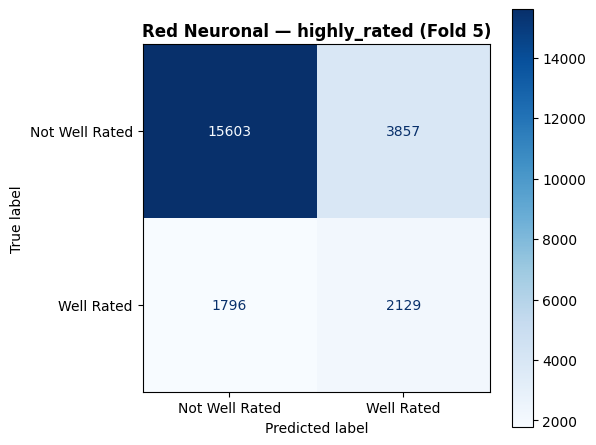


Classification Report — Red Neuronal (highly_rated):
                precision    recall  f1-score   support

Not Well Rated       0.90      0.80      0.85     19460
    Well Rated       0.36      0.54      0.43      3925

      accuracy                           0.76     23385
     macro avg       0.63      0.67      0.64     23385
  weighted avg       0.81      0.76      0.78     23385



In [13]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    yt1, yp1,
    display_labels=['Not Well Rated', 'Well Rated'],
    cmap='Blues', ax=ax
)
ax.set_title('Red Neuronal — highly_rated (Fold 5)', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nClassification Report — Red Neuronal (highly_rated):")
print(classification_report(
    yt1, yp1,
    target_names=['Not Well Rated', 'Well Rated']
))

Análisis de resultados

Los resultados obtenidos muestran que la red neuronal alcanzó una exactitud (Accuracy) del 76%, identificando correctamente la mayoría de las películas del conjunto de prueba. En particular, para la clase Not Well Rated, el modelo obtuvo una precisión del 90% y un recall del 80%, indicando una alta capacidad para reconocer películas que no son especialmente bien valoradas.

Para la clase Well Rated, que corresponde a la minoría del conjunto de datos, el modelo alcanzó una precisión de 36% y un recall de 54%, con un F1-Score de 43%. Esto significa que la red neuronal logra detectar más de la mitad de las películas bien calificadas, aunque todavía genera una cantidad considerable de falsos positivos. Este comportamiento es esperado debido al fuerte desbalance presente en el target, incluso después de aplicar técnicas de balanceo como SMOTE durante el entrenamiento.

Las métricas promedio (macro avg) muestran valores cercanos entre precisión (0.63) y recall (0.67), sugiriendo un desempeño relativamente equilibrado entre ambas clases. Por otro lado, el promedio ponderado (weighted avg) presenta valores más altos debido al predominio de la clase mayoritaria en el conjunto de datos.

Los resultados indican que la red neuronal consigue aprender patrones relevantes asociados a la valoración de las películas y presenta una capacidad de discriminación razonable para identificar títulos bien calificados. Sin embargo, la dificultad para mejorar la precisión de la clase minoritaria evidencia que la tarea sigue siendo compleja cuando se utilizan únicamente variables estructurales y de contenido, sin incorporar métricas directamente relacionadas con las calificaciones de los usuarios.

---
# 8. Clasificación 2: `success_category` (multiclase)
### Entrenamiento con validación cruzada 5-fold

La segunda tarea es un problema de clasificación multiclase. Aquí buscamos predecir en qué categoría de éxito cae cada película (Comercial Hit, Critically Acclaimed, Standard o Success), usando solo características estructurales y de contenido. Este problema es más complejo que el anterior porque ahora tenemos cuatro clases, están desbalanceadas y sus límites no son tan claros. Para evaluar el modelo usamos validación cruzada estratificada de 5 folds y aplicamos SMOTE dentro de cada partición de entrenamiento para reducir el desbalance entre categorías.



In [14]:
print("═"*55)
print("  CLASIFICACIÓN 2: success_category — Red Neuronal")
print("═"*55)

res_nn2, hist_nn2, yt2, yp2, yprob2 = evaluar_nn_cv(
    X_c2_scaled, y2_enc,
    build_fn=build_model_multiclass,
    task='multiclass',
    n_splits=5,
    epochs=100,
    batch_size=512,
    patience=10
)
res_nn2['Modelo'] = 'Red Neuronal — success_category'

═══════════════════════════════════════════════════════
  CLASIFICACIÓN 2: success_category — Red Neuronal
═══════════════════════════════════════════════════════
  Fold 1/5... (SMOTE: 240,160 muestras) F1=0.4487 | AUC=0.7195 | épocas=11
  Fold 2/5... (SMOTE: 240,160 muestras) F1=0.4817 | AUC=0.7464 | épocas=31
  Fold 3/5... (SMOTE: 240,160 muestras) F1=0.4697 | AUC=0.7515 | épocas=30
  Fold 4/5... (SMOTE: 240,160 muestras) F1=0.4478 | AUC=0.7205 | épocas=11
  Fold 5/5... (SMOTE: 240,160 muestras) F1=0.4484 | AUC=0.7218 | épocas=11

  ──────────────────────────────────────────────────
  Promedio 5-fold:
     Accuracy    : 0.4549
     Precision   : 0.6335
     Recall      : 0.4549
     F1-Score    : 0.4592
     AUC         : 0.7320
  Épocas promedio : 18.8


Los resultados muestran que la red neuronal alcanzó un Accuracy promedio del 45.49%, un F1-Score del 45.92% y un AUC de 0.7320. Aunque la exactitud es bastante más baja que en la tarea binaria, esto es esperable: es más difícil distinguir entre cuatro categorías de éxito cuando solo contamos con variables descriptivas de las películas.

El AUC de 0.73 nos dice que el modelo todavía es capaz de separar razonablemente bien las clases, aunque no siempre acierte con la categoría exacta. Además, el F1-Score se mantuvo estable entre folds (entre 0.44 y 0.48), lo que indica que el modelo es consistente y no depende demasiado de una partición específica de los datos.

Otro punto interesante es el número promedio de épocas que usó el modelo: solo 18.8. Esto es bastante menos que en la clasificación binaria. El mecanismo de Early Stopping hizo su trabajo: detuvo el entrenamiento cuando ya no veía mejoras en validación, lo que nos ahorró tiempo de cómputo y ayudó a evitar el sobreajuste.

En conjunto, estos resultados sugieren que la red neuronal logra captar algunos patrones relacionados con el éxito comercial y crítico de una película. Pero la complejidad del problema y la falta de variables más directas (como popularidad o valoraciones del público) limitan el rendimiento que podemos alcanzar con los datos que tenemos.

### Curvas de entrenamiento — Clasificación 2 (Fold 5)

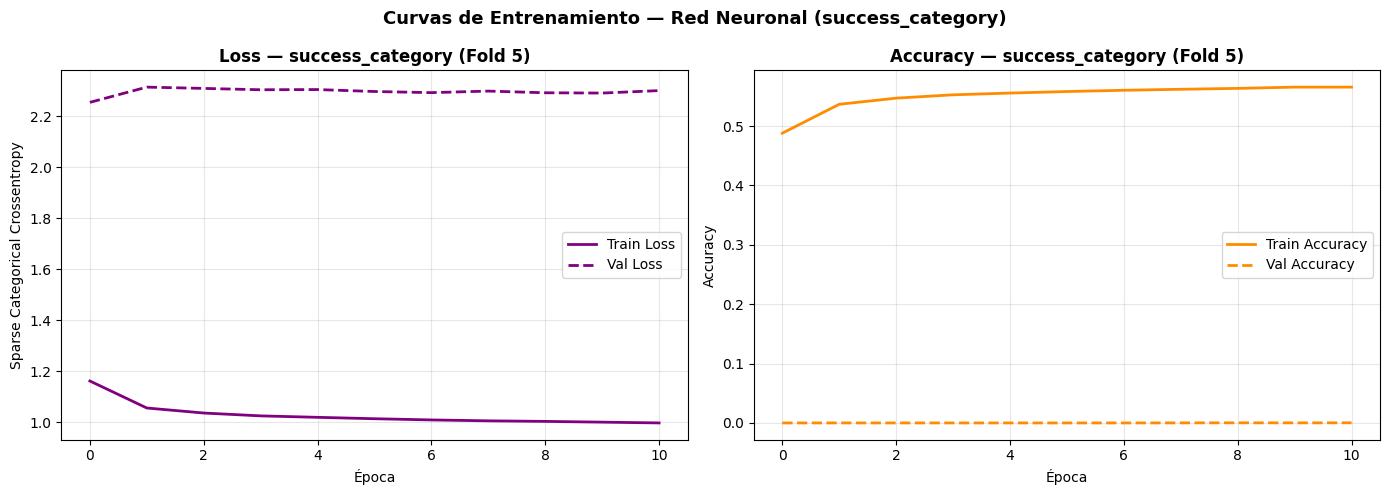

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist_nn2[-1]['loss'],
             label='Train Loss', color='purple', linewidth=2)
axes[0].plot(hist_nn2[-1]['val_loss'],
             label='Val Loss', color='purple', linestyle='--', linewidth=2)
axes[0].set_title('Loss — success_category (Fold 5)', fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Sparse Categorical Crossentropy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(hist_nn2[-1]['accuracy'],
             label='Train Accuracy', color='darkorange', linewidth=2)
axes[1].plot(hist_nn2[-1]['val_accuracy'],
             label='Val Accuracy', color='darkorange', linestyle='--', linewidth=2)
axes[1].set_title('Accuracy — success_category (Fold 5)', fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(
    'Curvas de Entrenamiento — Red Neuronal (success_category)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

En este caso, las curvas se comportaron distinto a lo que vimos en la clasificación binaria. La pérdida de entrenamiento baja progresivamente desde 1.17 hasta cerca de 1.00, lo que indica que la red sigue aprendiendo patrones de los datos con los que entrena. Sin embargo, la pérdida de validación se mantiene prácticamente constante alrededor de 2.30 durante todas las épocas, sin mostrar mejoras significativas.

Algo similar pasa con la precisión: la de entrenamiento sube gradualmente hasta el 56%, mientras que la de validación se mantiene cerca de cero durante todo el proceso. Esto suele ser señal de una gran diferencia entre lo que el modelo logra en entrenamiento y lo que logra en validación, lo que sugiere que en este fold particular el modelo tuvo problemas para generalizar.

Sin embargo, los resultados globales de la validación cruzada son mucho mejores (Accuracy ≈ 45% y AUC ≈ 0.73). Por eso, es probable que lo que vemos en esta gráfica sea una particularidad del último fold que usamos para visualizar,por esta razón, las conclusiones finales hay que sacarlas de los promedios de los cinco folds, no solo de las curvas de un fold individual.

Se observa que el modelo sí logra aprender representaciones útiles de los datos de entrenamiento, pero la clasificación multiclase sigue siendo una tarea mucho más desafiante que la clasificación binaria que hicimos con la variable highly_rated.


### Matriz de confusión y classification report — Clasificación 2 (Fold 5)

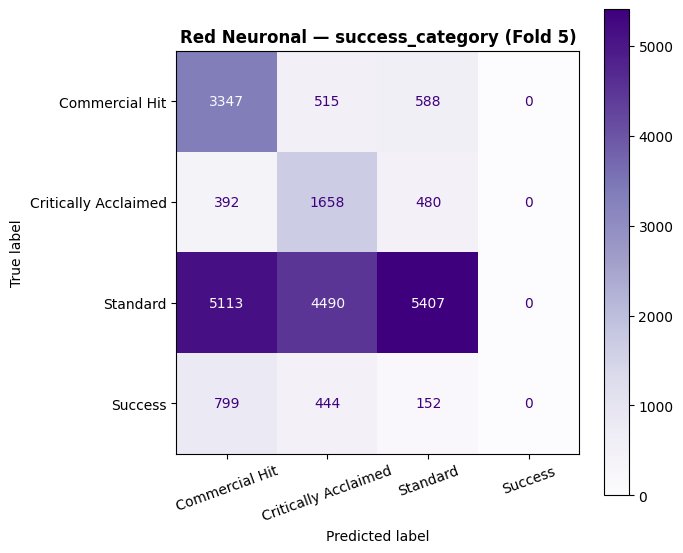


Classification Report — Red Neuronal (success_category):
                      precision    recall  f1-score   support

      Commercial Hit       0.35      0.75      0.47      4450
Critically Acclaimed       0.23      0.66      0.34      2530
            Standard       0.82      0.36      0.50     15010
             Success       0.00      0.00      0.00      1395

            accuracy                           0.45     23385
           macro avg       0.35      0.44      0.33     23385
        weighted avg       0.61      0.45      0.45     23385



In [16]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    yt2, yp2,
    display_labels=CLASS_NAMES,
    cmap='Purples', ax=ax, xticks_rotation=20
)
ax.set_title('Red Neuronal — success_category (Fold 5)', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nClassification Report — Red Neuronal (success_category):")
print(classification_report(yt2, yp2, target_names=CLASS_NAMES))

Los resultados muestran una Accuracy global de 45%, coherente con las métricas promedio obtenidas durante la validación cruzada. Sin embargo, el desempeño varía considerablemente entre las distintas categorías de éxito.

- La categoría Commercial Hit obtuvo un recall de 75%, lo que indica que el modelo logra identificar correctamente la mayoría de las películas con alto éxito comercial. No obstante, su precisión es de solo 35%, lo que significa que una proporción importante de las películas clasificadas como Commercial Hit realmente pertenecen a otras categorías.

- De forma similar, la categoría Critically Acclaimed presenta un recall de 66%, pero una precisión de apenas 23%. Esto sugiere que la red neuronal tiende a asignar esta clase con frecuencia, recuperando muchos casos reales pero generando también numerosos falsos positivos.

- La categoría Standard, que constituye la clase mayoritaria del conjunto de datos, alcanza la mejor precisión del modelo (82%). Esto indica que cuando la red predice esta categoría suele acertar. Sin embargo, el recall de 36% muestra que una gran cantidad de películas Standard son confundidas con otras clases, probablemente debido al efecto del balanceo realizado mediante SMOTE durante el entrenamiento.

- El caso más problemático corresponde a la categoría Success, para la cual el modelo obtiene precisión, recall y F1-Score iguales a cero. Esto significa que en el fold analizado la red no logró identificar correctamente ninguna película perteneciente a esta clase. Dado que Success representa apenas el 6% del conjunto de datos, se trata de la categoría más escasa y difícil de aprender, incluso después del sobremuestreo aplicado durante el entrenamiento.

---
## Resumen ejecutivo — Redes Neuronales

| Aspecto | Detalle |
|---|---|
| **Arquitectura** | Dense(64, relu) → Dropout(0.3) → Dense(32, relu) → Dropout(0.3) → Salida |
| **Optimizador** | Adam (lr=0.001 por defecto) |
| **Regularización** | Dropout 0.3 en ambas capas ocultas |
| **Desbalance** | `compute_class_weight('balanced')` de sklearn |
| **Early Stopping** | patience=5, monitorea val_loss, restaura mejores pesos |
| **Validación** | StratifiedKFold 5-fold, batch_size=256 |
| **C1 features** | 29 columnas (sin PC1 para evitar leakage con highly_rated) |
| **C2 features** | 30 columnas (incluye PC1) |

La métrica principal de comparación es **F1-Score** (weighted para multiclase, binary para clasificación 1), dado el desbalance de clases en ambas tareas.

# **9. Predicción de nuevas películas**

Una vez entrenados los modelos de redes neuronales, se implementó una función de inferencia que permite realizar predicciones sobre películas nuevas a partir de sus características básicas. La función recibe información como duración, año de lanzamiento, idioma, clasificación para adultos y géneros, aplicando exactamente el mismo preprocesamiento utilizado durante el entrenamiento (codificación de variables categóricas, transformación de géneros mediante MultiLabelBinarizer y escalado con StandardScaler). Posteriormente, los datos procesados son enviados a los modelos entrenados para estimar tanto la probabilidad de que una película sea highly_rated como la categoría de éxito (success_category) más probable.

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# PREDICCIÓN DE PELÍCULAS — Red Neuronal
# Predice si una película será 'Well Rated' y su 'success_category'
# usando solo características de contenido (sin ratings ni popularidad)
# ═══════════════════════════════════════════════════════════════════

# ── Re-entrenar modelos finales sobre TODO el dataset (sin CV) ───────────────
# Se usa el dataset completo balanceado con SMOTE para el modelo final
from imblearn.over_sampling import SMOTE

print('Entrenando modelos finales sobre dataset completo...')

smote = SMOTE(random_state=42)
X_c1_res, y1_res = smote.fit_resample(X_c1_scaled, y1)
X_c2_res, y2_res = smote.fit_resample(X_c2_scaled, y2_enc)

es_final = EarlyStopping(monitor='val_loss', patience=10,
                         restore_best_weights=True, verbose=0)

model_c1 = build_model_binary(X_c1_scaled.shape[1])
model_c1.fit(X_c1_res, y1_res, epochs=100, batch_size=512,
             validation_split=0.15, callbacks=[es_final], verbose=0)

es_final2 = EarlyStopping(monitor='val_loss', patience=10,
                          restore_best_weights=True, verbose=0)
model_c2 = build_model_multiclass(X_c2_scaled.shape[1], len(CLASS_NAMES))
model_c2.fit(X_c2_res, y2_res, epochs=100, batch_size=512,
             validation_split=0.15, callbacks=[es_final2], verbose=0)

print('Modelos listos.\n')


# ── Función de predicción ─────────────────────────────────────────────────────
def predecir_pelicula(
    titulo,
    generos,        # lista, ej: ['Action', 'Drama']
    runtime,        # minutos, ej: 120
    release_year,   # año, ej: 2019
    idioma,         # código ISO, ej: 'en', 'es', 'fr'
    adult=False
):
    """
    Predice para una película:
      - ¿Será bien valorada? (highly_rated, binaria)
      - ¿Cuál es su categoría de éxito? (success_category, 4 clases)

    Parámetros
    ----------
    titulo       : str  — nombre de la película (solo para display)
    generos      : list — géneros de la película (ver lista válida abajo)
    runtime      : int  — duración en minutos
    release_year : int  — año de estreno
    idioma       : str  — idioma original (código ISO 639-1)
    adult        : bool — contenido adulto (default False)

    Géneros válidos:
    Action, Adventure, Animation, Comedy, Crime, Documentary, Drama,
    Family, Fantasy, History, Horror, Music, Mystery, Romance,
    Science Fiction, TV Movie, Thriller, War, Western
    """

    # ── 1. Codificar duration_bin ─────────────────────────────────────────────
    if runtime <= 82:
        dur_enc = 0   # Short
        dur_label = 'Short'
    elif runtime <= 92:
        dur_enc = 1   # Standard
        dur_label = 'Standard'
    elif runtime <= 104:
        dur_enc = 2   # Long
        dur_label = 'Long'
    else:
        dur_enc = 3   # Very long
        dur_label = 'Very long'

    # ── 2. Codificar idioma ───────────────────────────────────────────────────
    top_langs_list = list(
        df['original_language'].value_counts().nlargest(10).index
    )
    lang_str = idioma if idioma in top_langs_list else 'other'
    lang_enc_val = le.transform([lang_str])[0]

    # ── 3. Codificar géneros (one-hot) ────────────────────────────────────────
    generos_norm = [g.strip() for g in generos]
    genre_vector = mlb.transform([generos_norm])[0]  # shape (19,)

    # ── 4. Construir vector de features ──────────────────────────────────────
    # Orden: runtime, release_year, adult_int, lang_encoded, duration_encoded + 19 géneros
    features = np.array([[
        float(runtime),
        float(release_year),
        float(int(adult)),
        float(lang_enc_val),
        float(dur_enc)
    ] + list(genre_vector.astype(float))], dtype=np.float32)

    # ── 5. Escalar (mismo scaler entrenado sobre X_c1) ────────────────────────
    features_scaled = scaler_c1.transform(features)

    # ── 6. Predicciones ───────────────────────────────────────────────────────
    prob_rated   = float(model_c1.predict(features_scaled, verbose=0)[0][0])
    prob_success = model_c2.predict(features_scaled, verbose=0)[0]  # shape (4,)
    pred_rated   = int(prob_rated >= 0.5)
    pred_success = int(np.argmax(prob_success))

    # ── 7. Display ────────────────────────────────────────────────────────────
    rated_label   = 'Well Rated ✅' if pred_rated == 1 else 'Not Well Rated ❌'
    success_label = CLASS_NAMES[pred_success]
    success_icons = {
        'Commercial Hit':      '💰',
        'Critically Acclaimed': '🏆',
        'Standard':            '📽️',
        'Success':             '🌟'
    }


In [21]:
def predecir_pelicula(
    titulo,
    generos,
    runtime,
    release_year,
    idioma,
    adult=False
):
    # ── 1. duration_bin ───────────────────────────────────────────────────────
    if runtime <= 82:
        dur_enc, dur_label = 0, 'Short'
    elif runtime <= 92:
        dur_enc, dur_label = 1, 'Standard'
    elif runtime <= 104:
        dur_enc, dur_label = 2, 'Long'
    else:
        dur_enc, dur_label = 3, 'Very long'

    # ── 2. Idioma ─────────────────────────────────────────────────────────────
    top_langs_list = list(df['original_language'].value_counts().nlargest(10).index)
    lang_str = idioma if idioma in top_langs_list else 'other'
    lang_enc_val = le.transform([lang_str])[0]

    # ── 3. Géneros ────────────────────────────────────────────────────────────
    generos_norm = [g.strip() for g in generos]
    genre_vector = mlb.transform([generos_norm])[0]

    # ── 4. Vector de features ─────────────────────────────────────────────────
    features = np.array([[
        float(runtime), float(release_year),
        float(int(adult)), float(lang_enc_val), float(dur_enc)
    ] + list(genre_vector.astype(float))], dtype=np.float32)

    features_scaled = scaler_c1.transform(features)

    # ── 5. Predicciones ───────────────────────────────────────────────────────
    prob_rated   = float(model_c1.predict(features_scaled, verbose=0)[0][0])
    prob_success = model_c2.predict(features_scaled, verbose=0)[0]
    pred_rated   = int(prob_rated >= 0.5)
    pred_success = int(np.argmax(prob_success))

    rated_label   = 'Well Rated ✅' if pred_rated == 1 else 'Not Well Rated ❌'
    success_label = CLASS_NAMES[pred_success]
    success_icons = {
        'Commercial Hit':       '💰',
        'Critically Acclaimed': '🏆',
        'Standard':             '📽️',
        'Success':              '🌟'
    }

    # ── 6. Display (fix: formatear % antes de alinear) ────────────────────────
    prob_rated_str = f'{prob_rated:.1%}'

    print(f'┌─────────────────────────────────────────────────────┐')
    print(f'│  🎬  {titulo:<47}│')
    print(f'├─────────────────────────────────────────────────────┤')
    print(f'│  Géneros    : {str(generos_norm):<38}│')
    print(f'│  Duración   : {runtime} min ({dur_label}){"":>20}│')
    print(f'│  Año        : {release_year:<38}│')
    print(f'│  Idioma     : {idioma:<38}│')
    print(f'├─────────────────────────────────────────────────────┤')
    print(f'│  Highly Rated   → {rated_label:<33}│')
    print(f'│  Probabilidad   → {prob_rated_str:<33}│')
    print(f'├─────────────────────────────────────────────────────┤')
    print(f'│  Success Cat → {success_icons[success_label]} {success_label:<35}│')
    print(f'│  Probabilidades por clase:                          │')
    for cname, cprob in sorted(zip(CLASS_NAMES, prob_success), key=lambda x: -x[1]):
        prob_str = f'{float(cprob):.1%}'
        bar = '█' * int(float(cprob) * 20)
        print(f'│    {cname:<22}: {prob_str:<6} {bar:<20}│')
    print(f'└─────────────────────────────────────────────────────┘')
    print()

    return {
        'highly_rated': pred_rated,
        'prob_highly_rated': round(prob_rated, 4),
        'success_category': success_label,
        'prob_success': {name: round(float(p), 4) for name, p in zip(CLASS_NAMES, prob_success)}
    }


# ── Ejemplos ──────────────────────────────────────────────────────────────────
predecir_pelicula('Avatar: The Way of Water',    ['Action', 'Adventure', 'Science Fiction'], 192, 2022, 'en')
predecir_pelicula('Drama Independiente Europeo', ['Drama', 'Romance'],                        98, 2018, 'fr')
predecir_pelicula('Slasher Genérico',            ['Horror', 'Thriller'],                      75, 2015, 'en')
predecir_pelicula('Documental de Naturaleza',    ['Documentary'],                             90, 2020, 'en')
predecir_pelicula('Película Animada Familiar',   ['Animation', 'Family', 'Comedy'],           95, 2023, 'en')
predecir_pelicula('Mi Película Personalizada',   ['Crime', 'Mystery', 'Thriller'],           110, 2021, 'ko')

┌─────────────────────────────────────────────────────┐
│  🎬  Avatar: The Way of Water                       │
├─────────────────────────────────────────────────────┤
│  Géneros    : ['Action', 'Adventure', 'Science Fiction']│
│  Duración   : 192 min (Very long)                    │
│  Año        : 2022                                  │
│  Idioma     : en                                    │
├─────────────────────────────────────────────────────┤
│  Highly Rated   → Well Rated ✅                     │
│  Probabilidad   → 74.3%                            │
├─────────────────────────────────────────────────────┤
│  Success Cat → 🌟 Success                            │
│  Probabilidades por clase:                          │
│    Success               : 57.9%  ███████████         │
│    Commercial Hit        : 30.2%  ██████              │
│    Critically Acclaimed  : 6.9%   █                   │
│    Standard              : 5.0%   █                   │
└─────────────────────────────────────

{'highly_rated': 1,
 'prob_highly_rated': 0.5664,
 'success_category': 'Commercial Hit',
 'prob_success': {'Commercial Hit': 0.3002,
  'Critically Acclaimed': 0.2709,
  'Standard': 0.2307,
  'Success': 0.1982}}

Esta función simula un escenario real de despliegue (inference), donde el sistema recibe información de una película y genera automáticamente una predicción. Además de la clase estimada, el modelo devuelve las probabilidades asociadas a cada resultado, lo que permite interpretar el nivel de confianza de la red neuronal en sus decisiones.

Los ejemplos incluidos abarcan distintos tipos de películas, desde grandes producciones comerciales como Avatar: The Way of Water hasta documentales, películas animadas y producciones independientes. Esto permite verificar que el flujo completo de procesamiento funciona correctamente para diferentes combinaciones de géneros, idiomas y duraciones.

Desde una perspectiva práctica, esta etapa demuestra que el modelo desarrollado no solo puede ser evaluado mediante métricas académicas como Accuracy, F1-Score o AUC, sino que también puede utilizarse para generar predicciones individuales sobre nuevas observaciones. En un contexto real, una implementación de este tipo podría emplearse como sistema de apoyo para estimar el potencial éxito o recepción crítica de futuras producciones cinematográficas a partir de sus características descriptivas.